# Biostatistical and Machine Learning Approaches to Cardiometabolic Risk Prediction in NHANES

# Overview

This project explores cardiometabolic risk using data from the National Health and Nutrition Examination Survey (NHANES).

The goal is to combine **biostatistical modelling** and **machine learning techniques** to better understand how demographic, clinical, and laboratory variables relate to key health outcomes such as blood pressure and diabetes.

Rather than relying on a single modelling approach, this analysis applies multiple methods—each serving a different purpose:
- statistical models for **interpretation and inference**
- machine learning models for **prediction and performance**
- unsupervised methods for **pattern discovery**

This reflects a real-world analytical workflow where both interpretability and predictive accuracy are important.

# Project Goals

The main objectives of this project are:

- Investigate relationships between risk factors (age, BMI, glucose, cholesterol) and cardiometabolic outcomes
- Build and interpret statistical models (linear and Poisson regression)
- Develop classification models to predict diabetes status
- Compare interpretable models with machine learning approaches
- Identify underlying population structure using PCA and clustering
- Apply hypothesis testing to evaluate group differences

Overall, this project demonstrates how different analytical approaches can be combined to study population health data.

# Methods 

The following methods are used in this project:

### Regression Models
- **Multiple Linear Regression**  
  Used to model systolic blood pressure as a continuous outcome

- **Poisson Regression**  
  Used to model a count-based cardiometabolic risk score

---

### Classification Models
- **Logistic Regression**  
  Provides interpretable relationships between predictors and diabetes risk

- **K-Nearest Neighbours (KNN)**  
  Captures non-linear patterns in the data

- **Random Forest**  
  Used for performance comparison and feature importance

---

### Unsupervised Learning
- **Principal Component Analysis (PCA)**  
  Reduces dimensionality and helps visualize structure

- **K-Means Clustering**  
  Identifies groups with similar metabolic profiles

---

### Statistical Testing
- **t-test**  
  Compares differences between groups (e.g., diabetic vs non-diabetic)

- **Regression inference**  
  Evaluates significance of predictors in statistical models

# Data Description

This project uses publicly available data from the **:contentReference[oaicite:0]{index=0}**, conducted by the :contentReference[oaicite:1]{index=1}.


---

## Data Sources 

All datasets used in this project come from the **2021–2023 NHANES cycle** and are linked using the unique participant identifier `SEQN`.

### 1. Demographics Data
- Contains: age, gender, race, socioeconomic variables  
- File: `DEMO_L.xpt`  
- Download:  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt  

---

### 2. Examination Data

#### Body Measures (BMI)
- Contains: BMI, height, weight  
- File: `BMX_L.xpt`  
- Download:  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.xpt  

#### Blood Pressure
- Contains: systolic and diastolic blood pressure readings  
- File: `BPXO_L.xpt`  
- Download:  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BPXO_L.xpt  

---

### 3. Laboratory Data

#### Glucose
- Contains: blood glucose levels (diabetes indicator)  
- File: `GLU_L.xpt`  
- Download:  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/GLU_L.xpt  

#### Cholesterol
- Contains: total cholesterol levels  
- File: `TCHOL_L.xpt`  
- Download:  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TCHOL_L.xpt  

---

## Data Integration

All datasets are merged using:
- **SEQN** (unique participant identifier)

This allows us to combine:
- demographic characteristics  
- clinical measurements  
- laboratory biomarkers  

into a unified analytical dataset.

---

- Data is provided in **SAS Transport (.XPT) format**
- Missing values are common and handled during preprocessing
- Blood pressure may include multiple readings per participant
- The dataset is cross-sectional not longitudinal


# IMPORT LIBRARIES

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

import statsmodels.api as sm
from scipy import stats


# LOADING DATA

In [58]:
sns.set_style("whitegrid")

demo = pd.read_sas("DEMO_L.xpt")
bmi = pd.read_sas("BMX_L.xpt")
bp = pd.read_sas("BPXO_L.xpt")
glu = pd.read_sas("GLU_L.xpt")
chol = pd.read_sas("TCHOL_L.xpt")

# Merge datasets
df = demo.merge(bmi, on="SEQN") \
         .merge(bp, on="SEQN") \
         .merge(glu, on="SEQN") \
         .merge(chol, on="SEQN")
df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,WTSAF2YR,LBXGLU,LBDGLUSI,WTPH2YR,LBXTC,LBDTCSI
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,94.0,82.0,79.0,82.0,1.200253e+05,113.0,6.27,56042.129410,264.0,6.83
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,76.0,72.0,71.0,73.0,5.397605e-79,99.0,5.50,37435.705647,214.0,5.53
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,76.0,84.0,83.0,77.0,1.450908e+05,156.0,8.66,85328.844519,187.0,4.84
3,130386.0,12.0,2.0,1.0,34.0,NaN,1.0,1.0,1.0,NaN,...,75.0,59.0,64.0,64.0,8.259962e+04,100.0,5.55,44526.214135,183.0,4.73
4,130394.0,12.0,2.0,1.0,51.0,NaN,3.0,3.0,1.0,NaN,...,67.0,78.0,82.0,79.0,1.004203e+05,88.0,4.88,52478.876664,183.0,4.73


# DATA CLEANING

In [59]:
# Selecting relevant variables
df = df[[
    "SEQN","RIAGENDR","RIDAGEYR",
    "BMXBMI","BPXOSY1","LBXGLU","LBXTC"
]]

df.columns = ["id","gender","age","bmi","sys_bp","glucose","cholesterol"]

# Droping missing values
df = df.dropna()


# Creating count variable for Poisson regression
df["diabetes"] = (
    (df["glucose"] >= 126) |
    ((df["bmi"] >= 30) & (df["glucose"] >= 110))
).astype(int)

df["hypertension"] = (df["sys_bp"] >= 130).astype(int)

df["risk_score"] = (
    (df["bmi"] >= 30).astype(int) +
    (df["sys_bp"] >= 130).astype(int) +
    (df["glucose"] >= 126).astype(int)
)

# EXPLORATORY DATA ANALYSIS

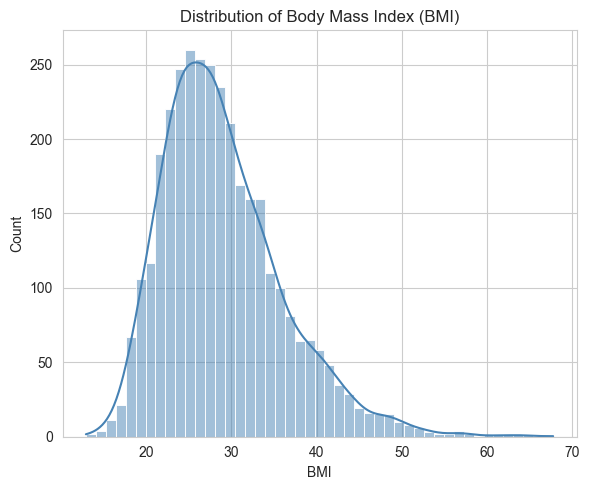

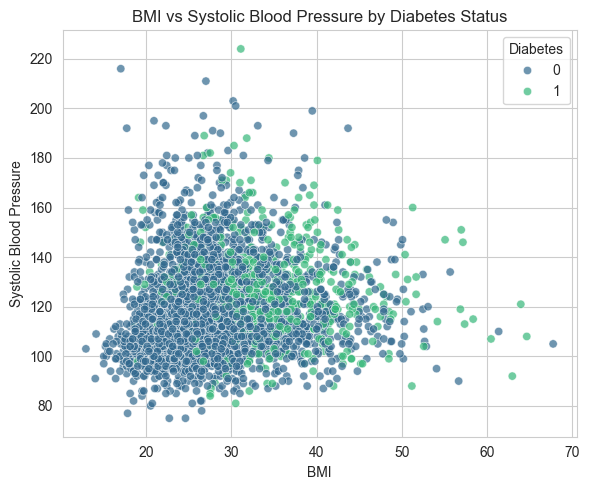

In [60]:
sns.set_style("whitegrid")

# BMI Distribution
plt.figure(figsize=(6,5))
sns.histplot(df["bmi"], kde=True, color="steelblue")

plt.title("Distribution of Body Mass Index (BMI)")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


# BMI vs Blood Pressure (colored by diabetes)
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="bmi",
    y="sys_bp",
    data=df,
    hue="diabetes",
    palette="viridis",
    alpha=0.7
)

plt.title("BMI vs Systolic Blood Pressure by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Systolic Blood Pressure")

plt.legend(title="Diabetes")
plt.tight_layout()
plt.show()

The distribution of Body Mass Index (BMI) appears right-skewed, with most individuals concentrated in the range of approximately 20–35. A smaller proportion of individuals exhibit higher BMI values, indicating the presence of overweight and obese subgroups within the population.

The scatter plot of BMI versus systolic blood pressure suggests a weak positive relationship, where higher BMI values are generally associated with slightly elevated blood pressure. However, the relationship is not strongly linear, indicating that additional factors likely influence blood pressure.

When stratified by diabetes status, individuals classified as diabetic tend to cluster at higher BMI levels and exhibit slightly higher systolic blood pressure on average. This pattern is consistent with known cardiometabolic risk profiles, where obesity is associated with both hypertension and diabetes.

Overall, these visualizations suggest that BMI is an important factor in cardiometabolic health, but its relationship with outcomes such as blood pressure and diabetes is influenced by multiple interacting variables rather than a single linear effect.

## Correlation Heatmap

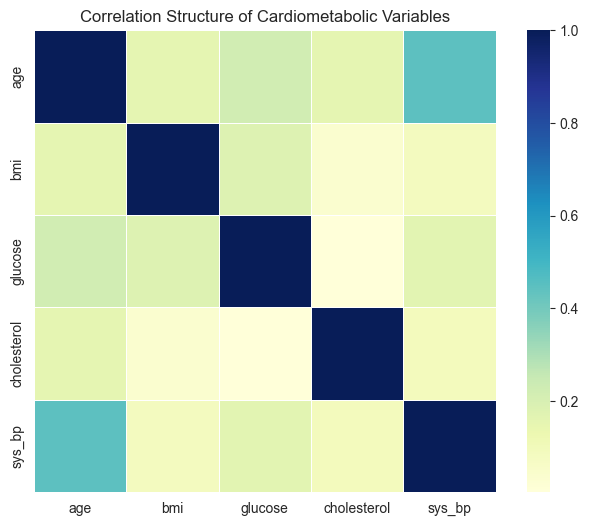

In [61]:
plt.figure(figsize=(8,6))

corr = df[["age","bmi","glucose","cholesterol","sys_bp"]].corr()

sns.heatmap(corr, cmap="YlGnBu", square=True, linewidths=0.5)
plt.title("Correlation Structure of Cardiometabolic Variables")
plt.show()

The correlation heatmap provides an overview of the linear relationships between key cardiometabolic variables, including age, BMI, glucose, cholesterol, and systolic blood pressure.

Overall, the correlations between most variables are relatively weak to moderate, suggesting limited multicollinearity. This indicates that each variable contributes distinct information, supporting their inclusion in multivariate models.

Age shows the strongest positive association with systolic blood pressure, consistent with well-established clinical evidence that blood pressure tends to increase with age. BMI and glucose also exhibit mild positive correlations with systolic blood pressure, suggesting that metabolic factors may contribute to elevated blood pressure, although the relationships are not strongly linear.

The correlations between BMI, glucose, and cholesterol are relatively low, indicating that these metabolic indicators capture different aspects of cardiometabolic health rather than representing redundant information.

Overall, the absence of strong correlations suggests that the dataset is suitable for regression and machine learning models without severe multicollinearity concerns. Additionally, the moderate and distributed relationships observed here support the use of dimensionality reduction techniques such as PCA to uncover underlying structure beyond simple pairwise associations.

# LINEAR REGRESSION

In [62]:
X = df[["age","bmi","glucose","cholesterol"]]
y = df["sys_bp"]

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 sys_bp   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     217.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          4.24e-166
Time:                        12:03:03   Log-Likelihood:                -14219.
No. Observations:                3382   AIC:                         2.845e+04
Df Residuals:                    3377   BIC:                         2.848e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          94.6593      1.813     52.201      

The multiple linear regression model was used to examine the association between demographic and metabolic variables (age, BMI, glucose, and cholesterol) and systolic blood pressure.

The model explains approximately 20.5% of the variance in systolic blood pressure (R² = 0.205), indicating that while these predictors are relevant, a substantial proportion of variability remains unexplained, likely due to additional clinical or lifestyle factors not included in the model.

Among the predictors, **age** shows a strong and statistically significant positive association with systolic blood pressure (p < 0.001). Specifically, each one-year increase in age is associated with an approximate increase of 0.38 units in systolic blood pressure, holding other variables constant. This finding aligns with established clinical evidence that blood pressure tends to increase with age.

**Glucose** is also positively and significantly associated with systolic blood pressure (p < 0.001), suggesting that higher glucose levels may reflect underlying metabolic dysregulation linked to elevated blood pressure.

In contrast, **BMI** does not show a statistically significant association (p = 0.648) in this multivariate context, indicating that its effect may be mediated through or confounded by other variables such as glucose or age. Similarly, **cholesterol** shows a weak and non-significant association (p = 0.092).

The overall model is statistically significant (F-statistic p < 0.001), indicating that the predictors collectively contribute to explaining variation in systolic blood pressure.

Diagnostic statistics suggest some deviation from normality in the residuals (as indicated by the Jarque-Bera test), although the Durbin-Watson statistic (~2.0) indicates no strong autocorrelation. The relatively large condition number may suggest some degree of multicollinearity or scaling differences, although this does not appear to substantially distort coefficient estimates.

Overall, these results highlight age and glucose as key factors associated with systolic blood pressure, while reinforcing the multifactorial nature of cardiometabolic risk.

# POISSON REGRESSION

In [63]:
X_p = sm.add_constant(df[["age","bmi","glucose"]])
y_p = df["risk_score"]

poisson_model = sm.GLM(y_p, X_p, family=sm.families.Poisson()).fit()
print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:             risk_score   No. Observations:                 3382
Model:                            GLM   Df Residuals:                     3378
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3091.0
Date:                Wed, 22 Apr 2026   Deviance:                       2027.9
Time:                        12:03:26   Pearson chi2:                 1.70e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3257
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8670      0.107    -36.234      0.0

A Poisson regression model was used to assess the relationship between age, BMI, and glucose and the cardiometabolic risk score, defined as the count of adverse health indicators.

All predictors—age, BMI, and glucose—are positively and statistically significantly associated with the risk score (p < 0.001), indicating that increases in these variables are associated with a higher accumulation of cardiometabolic risk factors.

Interpreting the coefficients in terms of incidence rate ratios (IRRs):

- **Age (coef ≈ 0.0186)**: Each additional year of age is associated with approximately a 1.9% increase in the expected risk score (exp(0.0186) ≈ 1.019), suggesting a gradual accumulation of risk over time.
- **BMI (coef ≈ 0.0633)**: Each one-unit increase in BMI is associated with approximately a 6.5% increase in the expected risk score (exp(0.0633) ≈ 1.065), indicating that BMI is the strongest contributor among the predictors.
- **Glucose (coef ≈ 0.0053)**: Each unit increase in glucose is associated with a modest (~0.5%) increase in expected risk score, reflecting a smaller but statistically significant contribution.

The model demonstrates moderate explanatory power (pseudo R² ≈ 0.33), which is reasonable given the multifactorial nature of cardiometabolic risk. A substantial proportion of variability remains unexplained, suggesting that additional behavioral, genetic, or environmental factors are not captured in this model.

It is important to note that the outcome variable (risk_score) is a constructed composite measure derived from clinical thresholds. As a result, some associations—particularly with BMI and glucose—may partially reflect how the outcome is defined, rather than entirely independent predictive relationships.

Overall, the results highlight BMI as the dominant contributor to cumulative cardiometabolic risk in this dataset, with age and glucose also playing significant roles. The findings support the use of count-based models to capture the combined burden of multiple risk factors, while also emphasizing the limitations of simplified composite outcomes.

# CLASSIFICATION MODELS

In [64]:
X = df[["age","bmi","cholesterol"]]
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Logistic Regression

In [65]:
log_model = LogisticRegression(class_weight="balanced")
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

## KNN

In [66]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8301329394387001


## Random Forest

In [68]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [69]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_model.predict(X_test_scaled)))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

Logistic Regression Accuracy: 0.6971935007385525
KNN Accuracy: 0.8301329394387001
Random Forest Accuracy: 0.8301329394387001


Three classification models—Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest—were evaluated for predicting diabetes status using demographic and metabolic features.

The results show clear differences in model performance:

- **Logistic Regression** achieved an accuracy of approximately 0.70, indicating moderate predictive performance. As a linear model, it provides interpretability but may not fully capture complex, non-linear relationships in the data.

- **KNN** achieved an accuracy of approximately 0.83, representing a substantial improvement over Logistic Regression. This suggests that local, non-linear patterns in the feature space are important for distinguishing between diabetic and non-diabetic individuals.

- **Random Forest** also achieved an accuracy of approximately 0.83, matching the performance of KNN. As an ensemble method, Random Forest is able to capture complex interactions between variables while maintaining robustness to noise and overfitting.

Overall, the results indicate that **non-linear models (KNN and Random Forest) outperform the linear Logistic Regression model**, suggesting that the relationship between predictors and diabetes status is not purely linear.

However, given the class imbalance in the dataset, accuracy alone may not fully reflect model performance. Logistic Regression was implemented with class weighting to address imbalance, which may partially explain its lower overall accuracy but potentially better sensitivity to the minority class.

These findings highlight a trade-off between interpretability and predictive performance: Logistic Regression provides more interpretable coefficients, while Random Forest and KNN offer improved predictive accuracy by capturing more complex patterns in the data.

# ROC CURVE

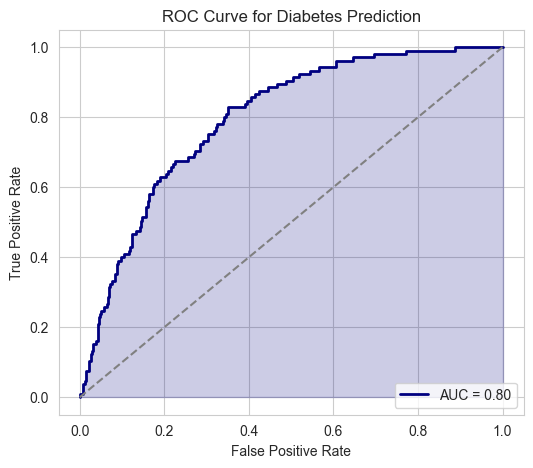

In [70]:
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="navy", linewidth=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--', color="gray")
plt.fill_between(fpr, tpr, alpha=0.2, color="navy")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Diabetes Prediction")
plt.legend(loc="lower right")
plt.show()

The Receiver Operating Characteristic (ROC) curve evaluates the ability of the Logistic Regression model to discriminate between diabetic and non-diabetic individuals across different classification thresholds.

The model achieves an Area Under the Curve (AUC) of approximately **0.80**, indicating good discriminatory performance. An AUC of 0.80 suggests that, on average, there is an 80% probability that the model will correctly rank a randomly selected diabetic individual higher than a randomly selected non-diabetic individual.

The ROC curve lies well above the diagonal reference line (which represents random guessing), demonstrating that the model performs substantially better than chance. The smooth upward curvature indicates a reasonable trade-off between sensitivity (true positive rate) and specificity (false positive rate) across thresholds.

From a clinical and practical perspective, an AUC of 0.80 reflects a **moderately strong predictive model**, particularly given the limited number of predictors and the inherent complexity of cardiometabolic conditions. This level of performance suggests that the model captures meaningful patterns in the data, though it is not sufficient for high-stakes clinical decision-making without further refinement.

Overall, the ROC analysis confirms that the Logistic Regression model provides reliable discrimination, while also highlighting opportunities for improvement through additional features or more flexible modelling approaches.

# FEATURE IMPORTANCE

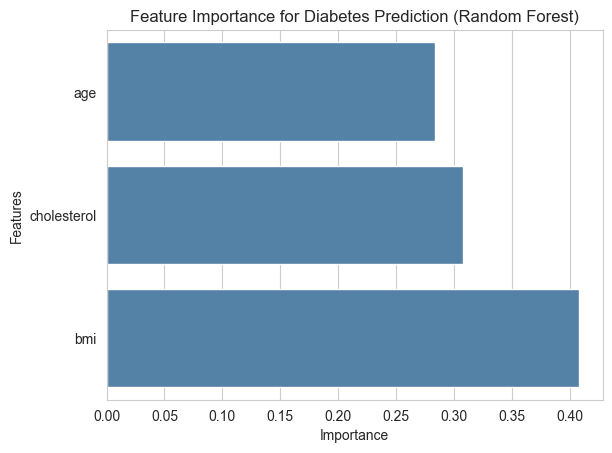

In [71]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values()

sns.barplot(x=feat_imp.values, y=feat_imp.index, color="steelblue")

plt.title("Feature Importance for Diabetes Prediction (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


The feature importance analysis from the Random Forest model highlights the relative contribution of each predictor in classifying diabetes status.

Among the variables, **BMI emerges as the most influential predictor**, with the highest importance score. This suggests that body mass index plays a central role in distinguishing between diabetic and non-diabetic individuals in this dataset, which is consistent with established evidence linking obesity to increased diabetes risk.

**Cholesterol** is the second most important feature, indicating that lipid levels also contribute meaningfully to the prediction of diabetes, potentially reflecting broader metabolic dysfunction.

**Age** shows a slightly lower but still substantial importance, suggesting that while age contributes to diabetes risk, its predictive power is somewhat less pronounced compared to BMI and cholesterol in this model.

Overall, the distribution of feature importance is relatively balanced, with no single variable overwhelmingly dominating the model. This indicates that the Random Forest is leveraging multiple aspects of cardiometabolic health to make predictions, rather than relying on a single predictor.

These findings reinforce the multifactorial nature of diabetes, where both anthropometric (BMI) and metabolic (cholesterol) factors, along with demographic characteristics (age), jointly contribute to disease risk.

It is important to note that feature importance in Random Forest reflects predictive contribution rather than causal effect, and may be influenced by variable scale and correlations.

# PCA 

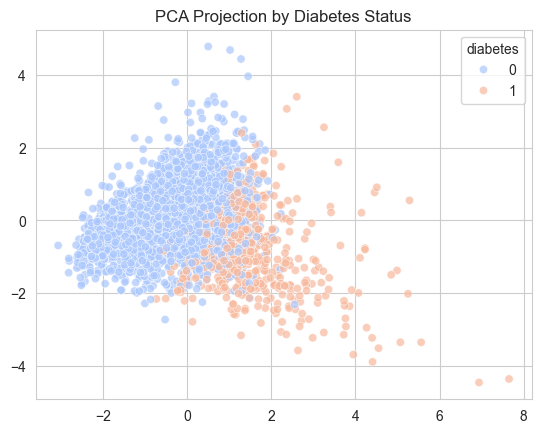

In [72]:
features = ["age","bmi","glucose","cholesterol"]
X_scaled = StandardScaler().fit_transform(df[features])

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

sns.scatterplot(
    x=components[:,0],
    y=components[:,1],
    hue=df["diabetes"],
    palette="coolwarm",
    alpha=0.7
)

plt.title("PCA Projection by Diabetes Status")
plt.show()


Principal Component Analysis (PCA) was applied to reduce the dimensionality of the cardiometabolic variables (age, BMI, glucose, and cholesterol) while preserving as much variance as possible.

The projection onto the first two principal components reveals partial separation between diabetic and non-diabetic individuals. Individuals with diabetes tend to cluster more toward the right-hand side of the plot (higher values of the first principal component), while non-diabetic individuals are more concentrated toward the left. This suggests that the first principal component captures a gradient of increasing cardiometabolic risk.

However, there is substantial overlap between the two groups, indicating that the separation is not complete. This overlap reflects the complexity of diabetes as a multifactorial condition and suggests that these variables alone do not fully discriminate between diabetic and non-diabetic individuals.

The spread of points also indicates variability within each group, highlighting heterogeneity in cardiometabolic profiles. While PCA helps reveal underlying structure in the data, it is not designed for classification, and the observed separation should be interpreted as exploratory rather than definitive.

Overall, the PCA results suggest that a combination of metabolic and demographic features contributes to diabetes status, but more flexible modelling approaches are required to capture non-linear relationships and improve classification performance.


# CLUSTERING (KMEANS)

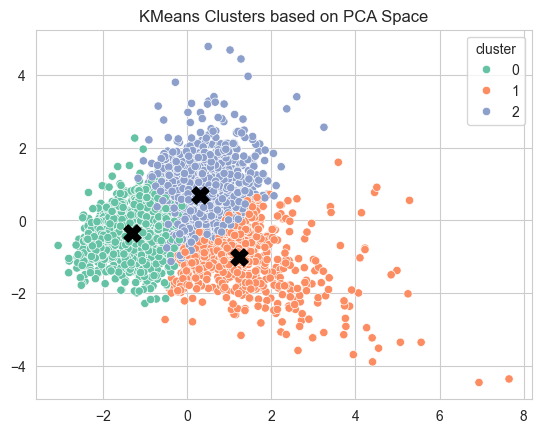

In [73]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

centroids = pca.transform(kmeans.cluster_centers_)

sns.scatterplot(
    x=components[:,0],
    y=components[:,1],
    hue=df["cluster"],
    palette="Set2"
)

plt.scatter(centroids[:,0], centroids[:,1], c="black", s=150, marker="X")
plt.title("KMeans Clusters based on PCA Space")
plt.show()


KMeans clustering was applied to the PCA-transformed cardiometabolic variables to identify potential subgroups within the population based on underlying data structure.

The algorithm identified three distinct clusters, which are visually separable in the reduced two-dimensional PCA space. The clusters appear to be primarily separated along the first principal component, suggesting that this dimension captures the dominant variation in cardiometabolic profiles.

Each cluster represents a group of individuals with similar combinations of age, BMI, glucose, and cholesterol. The spatial separation indicates that the dataset contains meaningful heterogeneity, with individuals naturally grouping into distinct cardiometabolic profiles rather than forming a single homogeneous population.

The cluster centroids (marked by black “X” symbols) represent the average position of each group and highlight the central tendency of the clusters. The relative positioning of these centroids suggests a gradient of cardiometabolic risk, with clusters located further to the right likely corresponding to higher-risk profiles.

However, some overlap between clusters is observed, indicating that boundaries between groups are not sharply defined. This reflects the continuous nature of cardiometabolic risk and suggests that clustering captures general patterns rather than strict categorical distinctions.

Overall, the clustering results demonstrate that unsupervised learning can reveal underlying structure in the data, identifying subpopulations that may differ in their cardiometabolic risk profiles. These findings complement the supervised models by providing an alternative perspective on the heterogeneity of the dataset.

Further characterization of clusters (e.g., comparing average BMI, glucose, and blood pressure across clusters) would provide deeper insight into their clinical relevance.

# CLUSTER PROFILING

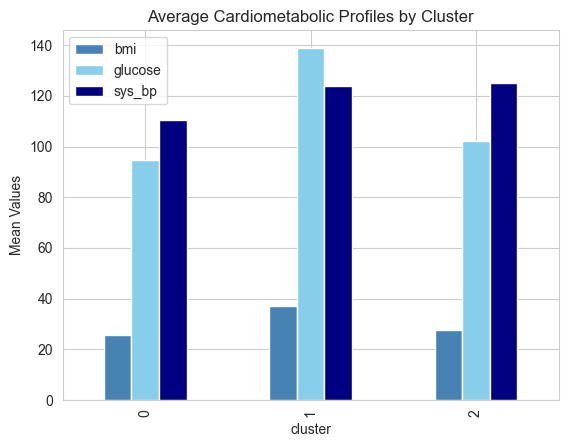

In [74]:
cluster_summary = df.groupby("cluster")[["bmi","glucose","sys_bp"]].mean()

cluster_summary.plot(kind="bar", color=["steelblue","skyblue","navy"])
plt.title("Average Cardiometabolic Profiles by Cluster")
plt.ylabel("Mean Values")
plt.show()

Cluster profiling was conducted to characterize the cardiometabolic differences between the groups identified by KMeans clustering. The mean values of BMI, glucose, and systolic blood pressure were compared across clusters to understand their clinical relevance.

The results reveal distinct cardiometabolic profiles for each cluster:

- **Cluster 1** appears to represent a **high-risk group**, with the highest average BMI and glucose levels, along with elevated systolic blood pressure. This suggests a subgroup characterized by obesity and metabolic dysregulation, consistent with a higher cardiometabolic risk profile.

- **Cluster 2** shows **moderately elevated blood pressure** but comparatively lower BMI and glucose than Cluster 1. This group may represent individuals with more isolated hypertension rather than broader metabolic dysfunction.

- **Cluster 0** represents a **lower-risk group**, with the lowest average BMI, glucose, and blood pressure levels, indicating a relatively healthier cardiometabolic profile.

These differences suggest that the clustering algorithm has successfully identified meaningful subpopulations with distinct combinations of risk factors. Importantly, the variation across clusters highlights that cardiometabolic risk is not uniform, but rather exists along multiple dimensions involving body composition, metabolic function, and cardiovascular indicators.

Overall, this analysis demonstrates that unsupervised learning can uncover clinically interpretable subgroups, complementing supervised models by providing insight into underlying population heterogeneity.

# HYPOTHESIS TESTING

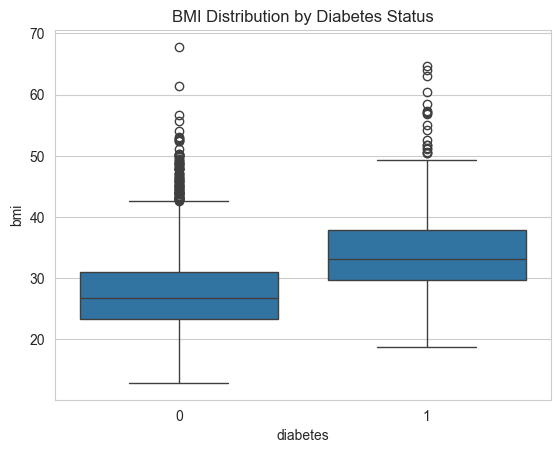

T-test Results
t-stat: 20.485335374482354
p-value: 5.219147319099363e-88


In [75]:
sns.boxplot(x="diabetes", y="bmi", data=df)
plt.title("BMI Distribution by Diabetes Status")
plt.show()

t_stat, p_val = stats.ttest_ind(
    df[df["diabetes"]==1]["bmi"],
    df[df["diabetes"]==0]["bmi"]
)

print("T-test Results")
print("t-stat:", t_stat)
print("p-value:", p_val)

A two-sample t-test was conducted to compare mean BMI between individuals with and without diabetes.

The boxplot indicates that individuals with diabetes tend to have higher BMI values, with a noticeably higher median and overall distribution compared to non-diabetic individuals. There is also greater spread and more extreme values in the diabetic group, suggesting increased variability in BMI among these individuals.

The t-test results show a **highly statistically significant difference** between the two groups (t ≈ 20.49, p < 0.001). Given the extremely small p-value (p ≈ 5.2 × 10⁻⁸⁸), we reject the null hypothesis that there is no difference in mean BMI between diabetic and non-diabetic individuals.

These findings provide strong evidence that BMI is significantly higher among individuals with diabetes in this dataset. This result is consistent with established clinical knowledge linking higher body mass index to increased risk of diabetes.

However, it is important to note that statistical significance does not imply causality. The observed association reflects correlation rather than a direct causal relationship, and may be influenced by confounding factors not accounted for in this analysis.

Overall, this hypothesis test supports the role of BMI as an important factor associated with diabetes status, reinforcing findings from both the regression and machine learning analyses.

## Conclusion

This project applied a combination of biostatistical modelling and machine learning techniques to investigate cardiometabolic risk factors using NHANES data.

Across multiple analytical approaches, several consistent findings emerged. Age, BMI, and glucose were identified as key variables associated with cardiometabolic outcomes. Linear and Poisson regression models demonstrated statistically significant relationships, with BMI showing the strongest association with cumulative risk. Hypothesis testing further confirmed that individuals with diabetes have significantly higher BMI, reinforcing the role of obesity in cardiometabolic disease.

From a predictive modelling perspective, non-linear models (KNN and Random Forest) outperformed Logistic Regression, suggesting that the relationship between predictors and diabetes status is not purely linear. The ROC analysis (AUC ≈ 0.80) indicated good discriminatory ability of the Logistic Regression model, providing a balance between interpretability and performance.

Unsupervised learning approaches (PCA and KMeans clustering) revealed underlying structure in the data, identifying distinct subgroups with different cardiometabolic profiles. Cluster profiling further demonstrated meaningful heterogeneity, with groups corresponding to lower-risk, intermediate-risk, and higher-risk profiles based on BMI, glucose, and blood pressure.

Overall, the results highlight the **multifactorial nature of cardiometabolic risk**, where demographic and metabolic variables jointly contribute to disease outcomes. The combination of statistical inference and machine learning provided complementary insights, strengthening the robustness of the findings.

---

## Next Steps

While the current analysis provides meaningful insights, several extensions could further strengthen the study:

1. **Incorporate Additional Variables**  
   Including lifestyle and behavioral factors (e.g., smoking status, physical activity, diet) and socioeconomic indicators would improve model performance and provide a more comprehensive understanding of cardiometabolic risk.

2. **Refine Outcome Definitions**  
   The use of a constructed risk score and simplified diabetes definition could be replaced with clinically validated outcomes (e.g., HbA1c-based diabetes diagnosis or composite cardiovascular risk scores) to enhance interpretability and real-world relevance.

3. **Evaluate Model Performance More Thoroughly**  
   Expanding evaluation metrics to include precision, recall, F1-score, and calibration curves would provide a more complete assessment, particularly in the presence of class imbalance.

4. **Address Model Assumptions and Extensions**  
   For count data, testing for overdispersion and considering alternative models such as Negative Binomial regression could improve model fit and inference.

5. **Enhance Feature Importance Analysis**  
   Applying permutation importance or SHAP values would provide more robust and interpretable insights into feature contributions.

6. **External Validation**  
   Validating the models on an independent dataset or different NHANES cycle would assess generalizability and robustness.

7. **Clinical Translation**  
   Future work could focus on translating these findings into risk stratification tools or decision-support systems for identifying high-risk individuals.

---

Overall, this project demonstrates the integration of statistical modelling and machine learning in a biostatistical context, highlighting both the strengths and limitations of different analytical approaches in understanding complex health data.